# Fanfooty Supercoach Prediction Model
Selecting your supercoach team is hard... this model is designed as a tool to assist supercoach users in selecting their team week-to-week.

This model uses rolling stats, opposition data, and past injury data to provide a predicted score for matches.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm
import time
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn import model_selection, ensemble, linear_model, svm
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, accuracy_score, roc_auc_score
from sklearn.impute import SimpleImputer
from tqdm import tqdm


pd.set_option('display.max_columns', 999)
pd.set_option('display.max_rows', 50)

In [2]:
timestr = time.strftime("%Y%m%d-%H%M%S")
destination = "exports/predict_fanfooty_{}".format(timestr)
os.mkdir(destination)

### Get Fanfooty Data
This data was scraped using scrape-fanfooty.pynb in this directory
- Remove bad SC data + convert set SC column as integer
- Create columns to allow merging with fixture data

In [3]:
df_fanfooty_player_raw = pd.read_csv(
    'exports/scrape_20250416-220941/fanfooty_match_data_20250416-220941.csv',
    dtype={
        'Fanfooty Match ID': 'int'
        # 'Player ID': 'int'
    },
    low_memory=False,
    index_col=0
)
df_fanfooty_player_raw = df_fanfooty_player_raw.loc[df_fanfooty_player_raw['SC'] != '-']
df_fanfooty_player_raw['SC'] = pd.to_numeric(df_fanfooty_player_raw['SC'], errors='coerce')
df_fanfooty_player_raw.dropna(subset=['Player ID', 'SC'], inplace=True)
df_fanfooty_player_raw['match_identifier'] = df_fanfooty_player_raw['Fanfooty Match ID'].astype(str) + '_' + df_fanfooty_player_raw['Team']
# df_fanfooty_player_raw['opposition_match_identifier'] = df_fanfooty_player_raw['Fanfooty Match ID'].astype(str) + '_' + df_fanfooty_player_raw['Opposition']

# calculate top 20% of players for that round
percentile_thresholds = df_fanfooty_player_raw.groupby(['Year', 'Round Order'])['SC'].quantile(0.80).reset_index()
percentile_thresholds.columns = ['Year', 'Round Order', '80th_percentile']
df_fanfooty_player_raw = pd.merge(df_fanfooty_player_raw, percentile_thresholds, on=['Year', 'Round Order'], how='left')
df_fanfooty_player_raw['top_20'] = (df_fanfooty_player_raw['SC'] >= df_fanfooty_player_raw['80th_percentile']).astype(int)

# calculate top 50% of players for that round
percentile_thresholds = df_fanfooty_player_raw.groupby(['Year', 'Round Order'])['SC'].quantile(0.50).reset_index()
percentile_thresholds.columns = ['Year', 'Round Order', '50th_percentile']
df_fanfooty_player_raw = pd.merge(df_fanfooty_player_raw, percentile_thresholds, on=['Year', 'Round Order'], how='left')
df_fanfooty_player_raw['top_50'] = (df_fanfooty_player_raw['SC'] >= df_fanfooty_player_raw['50th_percentile']).astype(int)

df_fanfooty_player_raw

,Fanfooty Match ID,Fanfooty Match URL,Round,Year,Player ID,First Name,Surname,Team,null,DT,SC,null2,null3,null4,Kicks,Handballs,Marks,Tackles,Hitouts,Frees for,Frees against,Goals,Behinds,Not sure,Tag,Tag Notes,Tag 2,Tag 2 Notes,null5,null6,null7,null8,Position,Jumper Number,null9,null10,null11,DT own %,SC own %,AF own %,null12,AF Breakeven,null13,Contested Possessions,Clearances,Clangers,Disposal efficiency,Time on ground,Metres gained,Bench staus,Injured,Opposition_team_SC,My_team_SC,Round Order,match_identifier,80th_percentile,top_20,50th_percentile,top_50
0,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,990020.0,Andrew,Embley,WC,30.0,111.0,98,144.0,79.0,112.0,20.0,8.0,1.0,6.0,1.0,1.0,0.0,1.0,0.0,Full Time,gun,Dempsey going with him... %s from %O and %T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,0,75.0,1
1,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,230254.0,Adam,Selwood,WC,50.0,107.0,107,143.0,79.0,108.0,10.0,9.0,4.0,11.0,0.0,3.0,2.0,1.0,0.0,Full Time,hot,Tagged by Lonergan... %D and %M with %T plus %s,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,1,75.0,1
2,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,200112.0,Dean,Cox,WC,27.0,99.0,118,114.0,88.0,106.0,9.0,10.0,2.0,2.0,30.0,4.0,1.0,1.0,1.0,Full Time,news,%H and %P with %s,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,1,75.0,1
3,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,240016.0,Beau,Waters,WC,26.0,98.0,84,130.0,79.0,117.0,15.0,13.0,5.0,6.0,0.0,0.0,4.0,0.0,0.0,Full Time,news,%P and %M with %F... clangers and FA dampening...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,0,75.0,1
4,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,261911.0,Brad,Ebert,WC,26.0,94.0,109,121.0,70.0,96.0,12.0,9.0,3.0,6.0,0.0,1.0,0.0,1.0,0.0,Full Time,news,Matched up on Winderlich... %D and %T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,1,75.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132935,9245,http://live.fanfooty.com.au/game/matchcentre.h...,R5,2025,1023473.0,Nick,Watson,HW,2.0,39.0,33,31.0,28.0,39.0,5.0,4.0,1.0,3.0,0.0,1.0,0.0,0.0,0.0,Full Time,missing,Never in the game at any stage... %P and %T,wing,Rotating at half forward,NaN,NaN,NaN,NaN,Midfielder,34.0,0.0,0.00,0.0,28.30,27.81,24.02,NaN,NaN,NaN,4.0,0.0,2.0,33.0,80.0,201.0,0.0,False,1799,1477,6,9245_HW,97.2,0,71.0,0
132936,9245,http://live.fanfooty.com.au/game/matchcentre.h...,R5,2025,1009421.0,Finn,Maginness,HW,4.0,37.0,31,34.0,34.0,49.0,3.0,9.0,2.0,2.0,0.0,1.0,2.0,0.0,1.0,Full Time,switch,%P including %B... also %M and %T... and kicke...,NaN,NaN,NaN,NaN,NaN,NaN,Midfielder,20.0,0.0,0.00,0.0,0.40,0.87,0.98,NaN,NaN,NaN,7.0,0.0,6.0,41.0,87.0,92.0,0.0,False,1799,1477,6,9245_HW,97.2,0,71.0,0
132937,9245,http://live.fanfooty.com.au/game/matchcentre.h...,R5,2025,993794.0,Blake,Hardwick,HW,3.0,36.0,26,24.0,28.0,36.0,6.0,1.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,Full Time,switch,%P including %K... also %M... In attack on Rat...,NaN,NaN,NaN,0.0,NaN,NaN,Back,15.0,21.0,66.67,0.0,0.00,0.10,0.18,NaN,NaN,NaN,1.0,0.0,1.0,71.0,83.0,171.0,1.0,False,1799,1477,6,9245_HW,97.2,0,71.0,0
132938,9245,http://live.fanfooty.com.au/game/matchcentre.h...,R5,2025,1012857.0,Jack,Ginnivan,HW,2.0,35.0,50,26.0,29.0,42.0,4.0,8.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,Full Time,pocket,%P... Playing a forward role,NaN,NaN,NaN,NaN,NaN,NaN,Forward,33.0,0.0,0.00,0.0,0.89,1.63,2.22,NaN,NaN,NaN,3.0,0.0,1.0,83.0,6

### Feature Building: Get the player's 3 round rolling stats, along with their rolling 20, 10, 5, 3, and 1 round Supercoach Scores

In [4]:
# Define the rolling_stat_list
rolling_stat_list = [
    'Kicks', 'Handballs', 'Marks', 'Tackles', 'Hitouts', 'Frees for', 'Frees against',
    'Goals', 'Behinds', 'DT own %', 'SC own %', 'AF own %', 'Contested Possessions',
    'Clearances', 'Clangers', 'Disposal efficiency', 'Time on ground', 'Metres gained',
    'My_team_SC', 'Opposition_team_SC'
]

# Function to calculate rolling average
def rolling_average(player, window):
    return player.shift(1).rolling(window=window).mean()

def get_tags(row, window):
    player_id = row['Player ID']
    current_round = row['recent_round_rank']
    previous_tags = df_fanfooty_player_raw[(df_fanfooty_player_raw['Player ID'] == player_id) & (df_fanfooty_player_raw['recent_round_rank'] < current_round)].sort_values(by='recent_round_rank', ascending=False)['Tag'].head(window).tolist()
    return previous_tags

df_fanfooty_player_raw = df_fanfooty_player_raw.sort_values(by=['Year', 'Round Order'])

# Group the DataFrame once
grouped = df_fanfooty_player_raw.groupby('Player ID', group_keys=False)
print('Grouped')

# Calculate rolling averages for each stat in rolling_stat_list
for stat in rolling_stat_list:
    df_fanfooty_player_raw[f"3_rd_rolling_{stat}"] = grouped[stat].transform(lambda x: rolling_average(x, 3))
    df_fanfooty_player_raw[f"15_rd_rolling_{stat}"] = grouped[stat].transform(lambda x: rolling_average(x, 15))
    print(stat)

    
# Calculate rolling averages for 'SC'
df_fanfooty_player_raw['rolling 20 round average'] = grouped['SC'].transform(lambda x: rolling_average(x, 20))
print('rolling 20 round average')
df_fanfooty_player_raw['rolling 10 round average'] = grouped['SC'].transform(lambda x: rolling_average(x, 10))
print('rolling 10 round average')
df_fanfooty_player_raw['rolling 5 round average'] = grouped['SC'].transform(lambda x: rolling_average(x, 5))
print('rolling 5 round average')
df_fanfooty_player_raw['rolling 3 round average'] = grouped['SC'].transform(lambda x: rolling_average(x, 3))
print('rolling 3 round average')

# Rank the games by most recent first
df_fanfooty_player_raw['recent_round_rank'] = df_fanfooty_player_raw.sort_values(by=['Year', 'Round Order'], ascending=[False, False]).groupby(['Player ID']).cumcount() + 1
print('recent_round_rank')

# Get the Tag and Tag 2 of previous match
df_fanfooty_player_raw['previous_tag'] = df_fanfooty_player_raw.apply(lambda row: get_tags(row, 1), axis=1)
df_fanfooty_player_raw['previous_tag'] = df_fanfooty_player_raw['previous_tag'].apply(lambda x: ' '.join(map(str, x)) if isinstance(x, list) else str(x))
print('previous_tag')
# df_fanfooty_player_raw['previous_3_tags'] = df_fanfooty_player_raw.apply(lambda row: get_tags(row, 3), axis=1)
# print('previous_3_tags')

# Filter data for a specific player
display(df_fanfooty_player_raw.loc[df_fanfooty_player_raw['Surname'] == 'Dangerfield', ['First Name', 'Surname', 'Year', 'Round', 'Round Order', 'recent_round_rank', 'SC', 'rolling 20 round average', 'rolling 10 round average', 'rolling 5 round average', 'rolling 3 round average', 'Tag', 'previous_tag'
                                                                                        # , 'previous_3_tags'
                                                                                       ]])
display(df_fanfooty_player_raw)

Grouped
Kicks
Handballs
Marks
Tackles
Hitouts
Frees for
Frees against
Goals
Behinds
DT own %
SC own %
AF own %
Contested Possessions
Clearances
Clangers
Disposal efficiency
Time on ground
Metres gained
My_team_SC
Opposition_team_SC
rolling 20 round average
rolling 10 round average
rolling 5 round average
rolling 3 round average
recent_round_rank
previous_tag


,First Name,Surname,Year,Round,Round Order,recent_round_rank,SC,rolling 20 round average,rolling 10 round average,rolling 5 round average,rolling 3 round average,Tag,previous_tag
99,Patrick,Dangerfield,2010,R4,5,310,52,NaN,NaN,NaN,NaN,down,sore
385,Patrick,Dangerfield,2010,R5,6,309,51,NaN,NaN,NaN,NaN,sore,tagged
1589,Patrick,Dangerfield,2010,R8,9,308,60,NaN,NaN,NaN,NaN,tagged,tagged
1943,Patrick,Dangerfield,2010,R9,10,307,85,NaN,NaN,NaN,54.333333,tagged,news
2268,Patrick,Dangerfield,2010,R10,11,306,69,NaN,NaN,NaN,65.333333,news,news
...,...,...,...,...,...,...,...,...,...,...,...,...,...
130923,Patrick,Dangerfield,2024,PF,33,5,72,84.50,83.4,93.0,96.333333,sore,midfwd
131201,Patrick,Dangerfield,2025,R1,2,4,80,84.85,82.5,90.0,90.000000,midfwd,midfwd
131720,Patrick,Dangerfield,2025,R2,3,3,74,83.85,83.6,88.2,83.333333,midfwd,star
132228,Patrick,Dangerfield,2025,R4,5,2,112,81.30,83.9,84.8,75.333333,star,x-factor


,Fanfooty Match ID,Fanfooty Match URL,Round,Year,Player ID,First Name,Surname,Team,null,DT,SC,null2,null3,null4,Kicks,Handballs,Marks,Tackles,Hitouts,Frees for,Frees against,Goals,Behinds,Not sure,Tag,Tag Notes,Tag 2,Tag 2 Notes,null5,null6,null7,null8,Position,Jumper Number,null9,null10,null11,DT own %,SC own %,AF own %,null12,AF Breakeven,null13,Contested Possessions,Clearances,Clangers,Disposal efficiency,Time on ground,Metres gained,Bench staus,Injured,Opposition_team_SC,My_team_SC,Round Order,match_identifier,80th_percentile,top_20,50th_percentile,top_50,3_rd_rolling_Kicks,15_rd_rolling_Kicks,3_rd_rolling_Handballs,15_rd_rolling_Handballs,3_rd_rolling_Marks,15_rd_rolling_Marks,3_rd_rolling_Tackles,15_rd_rolling_Tackles,3_rd_rolling_Hitouts,15_rd_rolling_Hitouts,3_rd_rolling_Frees for,15_rd_rolling_Frees for,3_rd_rolling_Frees against,15_rd_rolling_Frees against,3_rd_rolling_Goals,15_rd_rolling_Goals,3_rd_rolling_Behinds,15_rd_rolling_Behinds,3_rd_rolling_DT own %,15_rd_rolling_DT own %,3_rd_rolling_SC own %,15_rd_rolling_SC own %,3_rd_rolling_AF own %,15_rd_rolling_AF own %,3_rd_rolling_Contested Possessions,15_rd_rolling_Contested Possessions,3_rd_rolling_Clearances,15_rd_rolling_Clearances,3_rd_rolling_Clangers,15_rd_rolling_Clangers,3_rd_rolling_Disposal efficiency,15_rd_rolling_Disposal efficiency,3_rd_rolling_Time on ground,15_rd_rolling_Time on ground,3_rd_rolling_Metres gained,15_rd_rolling_Metres gained,3_rd_rolling_My_team_SC,15_rd_rolling_My_team_SC,3_rd_rolling_Opposition_team_SC,15_rd_rolling_Opposition_team_SC,rolling 20 round average,rolling 10 round average,rolling 5 round average,rolling 3 round average,recent_round_rank,previous_tag
0,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,990020.0,Andrew,Embley,WC,30.0,111.0,98,144.0,79.0,112.0,20.0,8.0,1.0,6.0,1.0,1.0,0.0,1.0,0.0,Full Time,gun,Dempsey going with him... %s from %O and %T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,0,75.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60,tagged
1,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,230254.0,Adam,Selwood,WC,50.0,107.0,107,143.0,79.0,108.0,10.0,9.0,4.0,11.0,0.0,3.0,2.0,1.0,0.0,Full Time,hot,Tagged by Lonergan... %D and %M with %T plus %s,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,1,75.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66,tagger
2,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,200112.0,Dean,Cox,WC,27.0,99.0,118,114.0,88.0,106.0,9.0,10.0,2.0,2.0,30.0,4.0,1.0,1.0,1.0,Full Time,news,%H and %P with %s,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,1,75.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,104,hot
3,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,240016.0,Beau,Waters,WC,26.0,98.0,84,130.0,79.0,117.0,15.0,13.0,5.0,6.0,0.0,0.0,4.0,0.0,0.0,Full Time,news,%P and %M with %F... clangers and FA dampening...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,0,75.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56,hot
4,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,261911.0,Brad,Ebert,WC,26.0,94.0,109,121.0,70.0,96.0,12.0,9.0,3.0,6.0,0.0,1.0,0.0,1.0,0.0,Full Time,news,Matched up 

In [5]:

df_predicted_scores = []

# Load your data into a DataFrame
df = df_fanfooty_player_raw

# Define features
features = [
    '3_rd_rolling_Kicks', 'rolling 20 round average', '15_rd_rolling_Clangers', '15_rd_rolling_Behinds',
    '15_rd_rolling_Handballs', '15_rd_rolling_Kicks', '3_rd_rolling_Behinds',
    '3_rd_rolling_Handballs', '3_rd_rolling_Goals', '3_rd_rolling_My_team_SC', '15_rd_rolling_My_team_SC',
    '3_rd_rolling_Opposition_team_SC', '15_rd_rolling_Opposition_team_SC', 'previous_tag'
]
df_fanfooty_player_raw['Tag'].fillna('')

# Separate numeric and categorical features
numeric_features = [
    '3_rd_rolling_Kicks', 'rolling 20 round average', '15_rd_rolling_Clangers', '15_rd_rolling_Behinds',
    '15_rd_rolling_Handballs', '15_rd_rolling_Kicks', '3_rd_rolling_Behinds',
    '3_rd_rolling_Handballs', '3_rd_rolling_Goals', '3_rd_rolling_My_team_SC', '15_rd_rolling_My_team_SC',
    '3_rd_rolling_Opposition_team_SC', '15_rd_rolling_Opposition_team_SC'
]
categorical_features = ['previous_tag']

# Preprocessing for numeric data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])



In [6]:
target = 'SC'

df_fanfooty_data_clean = df_fanfooty_player_raw.dropna(subset=features + [target])

X = df_fanfooty_data_clean.loc[:, features]
y = df_fanfooty_data_clean[target]

# Train/test split
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.30)

# Create a pipeline with the preprocessor and LinearRegression
pipeline_sc_score = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression()
    )
])

# Train the model with a progress bar
for _ in tqdm(range(1), desc="Training model"):
    pipeline_sc_score.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline_sc_score.predict(X_test)

evaluate = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred,
    "diff": y_test - y_pred
})

# Calculate and print the mean squared error
mse = round(mean_squared_error(y_test, y_pred), 2)
print(f'Mean Squared Error: {mse}')

# Evaluate
df_predicted_scores = pd.merge(df_fanfooty_player_raw, evaluate, left_index=True, right_index=True)
df_predicted_scores.to_csv("{}/predict_fanfooty_sc_score_{}.csv".format(destination, timestr))
df_predicted_scores

Training model: 100%|████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.61it/s]


Mean Squared Error: 615.2


,Fanfooty Match ID,Fanfooty Match URL,Round,Year,Player ID,First Name,Surname,Team,null,DT,SC,null2,null3,null4,Kicks,Handballs,Marks,Tackles,Hitouts,Frees for,Frees against,Goals,Behinds,Not sure,Tag,Tag Notes,Tag 2,Tag 2 Notes,null5,null6,null7,null8,Position,Jumper Number,null9,null10,null11,DT own %,SC own %,AF own %,null12,AF Breakeven,null13,Contested Possessions,Clearances,Clangers,Disposal efficiency,Time on ground,Metres gained,Bench staus,Injured,Opposition_team_SC,My_team_SC,Round Order,match_identifier,80th_percentile,top_20,50th_percentile,top_50,3_rd_rolling_Kicks,15_rd_rolling_Kicks,3_rd_rolling_Handballs,15_rd_rolling_Handballs,3_rd_rolling_Marks,15_rd_rolling_Marks,3_rd_rolling_Tackles,15_rd_rolling_Tackles,3_rd_rolling_Hitouts,15_rd_rolling_Hitouts,3_rd_rolling_Frees for,15_rd_rolling_Frees for,3_rd_rolling_Frees against,15_rd_rolling_Frees against,3_rd_rolling_Goals,15_rd_rolling_Goals,3_rd_rolling_Behinds,15_rd_rolling_Behinds,3_rd_rolling_DT own %,15_rd_rolling_DT own %,3_rd_rolling_SC own %,15_rd_rolling_SC own %,3_rd_rolling_AF own %,15_rd_rolling_AF own %,3_rd_rolling_Contested Possessions,15_rd_rolling_Contested Possessions,3_rd_rolling_Clearances,15_rd_rolling_Clearances,3_rd_rolling_Clangers,15_rd_rolling_Clangers,3_rd_rolling_Disposal efficiency,15_rd_rolling_Disposal efficiency,3_rd_rolling_Time on ground,15_rd_rolling_Time on ground,3_rd_rolling_Metres gained,15_rd_rolling_Metres gained,3_rd_rolling_My_team_SC,15_rd_rolling_My_team_SC,3_rd_rolling_Opposition_team_SC,15_rd_rolling_Opposition_team_SC,rolling 20 round average,rolling 10 round average,rolling 5 round average,rolling 3 round average,recent_round_rank,previous_tag,actual,predicted,diff
46174,5309,http://live.fanfooty.com.au/game/matchcentre.h...,R14,2015,260382.0,Josh P.,Kennedy,SY,44.0,151.0,143,192.0,119.0,159.0,18.0,15.0,7.0,8.0,0.0,2.0,1.0,2.0,3.0,Full Time,star,Massive Q1 with a few opportunist goals rotati...,NaN,NaN,392900.0,92.0,479000.0,74.0,Midfielder,12.0,11.0,71.10,104.0,0.82,19.40,6.71,516000.0,99.0,NaN,17.0,11.0,2.0,60.0,86.0,NaN,NaN,False,1579,1702,15,5309_SY,101.4,1,74.0,1,11.000000,11.400000,15.000000,15.866667,2.333333,3.000000,4.333333,5.666667,0.000000,0.133333,1.000000,0.800000,1.000000,1.000000,0.333333,0.333333,1.333333,0.800000,0.906667,5.318667,16.726667,14.811333,6.800000,8.420000,13.000000,14.933333,5.666667,6.933333,4.000000,3.266667,57.333333,64.733333,59.000000,74.933333,NaN,NaN,1745.333333,1702.400000,1489.000000,1546.600000,99.80,98.1,89.4,90.000000,139,magnet,143,98.337216,44.662784
46182,5309,http://live.fanfooty.com.au/game/matchcentre.h...,R14,2015,290307.0,Dane,Rampe,SY,9.0,65.0,92,84.0,52.0,69.0,7.0,7.0,6.0,3.0,0.0,0.0,0.0,0.0,0.0,Full Time,news,%P and %M plus %T,job,Had Monfries to start then moved to Schulz in ...,102900.0,NaN,453400.0,113.0,Back,24.0,0.0,0.00,81.2,0.60,2.33,2.11,382000.0,49.0,NaN,5.0,0.0,0.0,78.0,94.0,NaN,NaN,False,1579,1702,15,5309_SY,101.4,0,74.0,1,15.333333,10.333333,8.666667,6.266667,10.000000,4.666667,1.333333,2.466667,0.000000,0.000000,0.333333,0.333333,0.333333,1.200000,0.000000,0.000000,0.333333,0.066667,0.580000,0.734000,2.073333,1.760000,1.690000,1.510000,6.000000,4.066667,0.000000,0.266667,1.666667,2.466667,74.666667,79.466667,57.000000,75.000000,NaN,NaN,1745.333333,1702.400000,1489.000000,1546.600000,73.80,78.1,95.2,96.666667,193,hot,92,85.624370,6.375630
46183,5309,http://live.fanfooty.com.au/game/matchcentre.h...,R14,2015,281281.0,Lewis,Jetta,SY,9.0,61.0,61,82.0,43.0,61.0,14.0,0.0,1.0,3.0,0.0,0.0,1.0,1.0,1.0,Full Time,astronaut,Matched up on Impey... very outside all night....,NaN,NaN,102900.0,NaN,472900.0,125.0,Forward,32.0,0.0,0.00,83.8,0.96,2.27,1.98,468000.0,101.0,NaN,2.0,0.0,3.0,71.0,90.0,NaN,NaN,False,1579,1702,15,5309_SY,101.4,0,74.0,0,14.666667,12.400000,6.333333,5.800000,4.666667,3.933333,2.666667,2.666667,0.000000,0.000000,0.000000,0.333333,0.000000,0.533333,0.333333,0.533333,0.000000,0.600000,0.906667,1.391333,2.090000,2.105333,1.830000,2.350667,3.666667,

### View and plot the predictions for a specific player... Patrick Dangerfield!

,actual,predicted
recent_round_rank,,
187,77,122.319666
186,77,121.362562
179,86,112.638329
175,173,129.325792
171,111,122.134463
...,...,...
16,94,87.556827
15,81,86.095448
11,60,80.655422


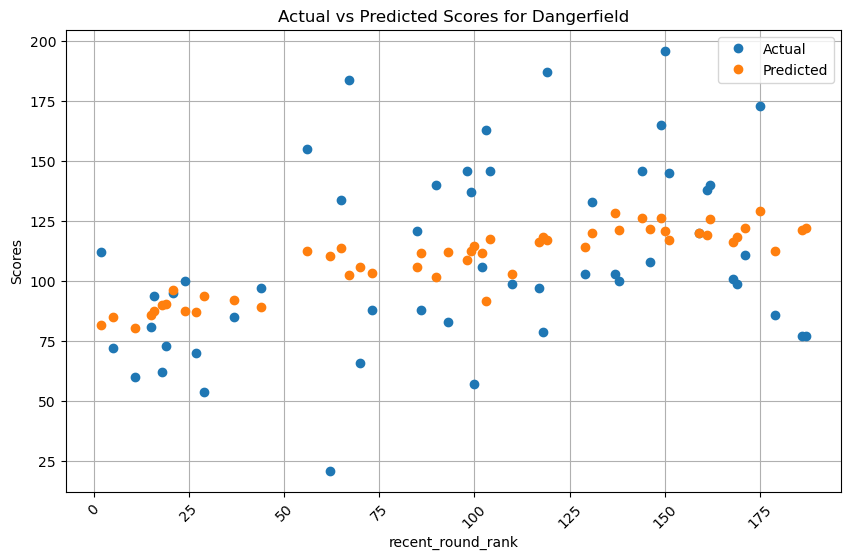

In [7]:
df_player = df_predicted_scores.loc[df_predicted_scores['Surname'] == 'Dangerfield']
df_player = df_player[['recent_round_rank', 'actual', 'predicted']]
df_player = df_player.set_index('recent_round_rank')

# Display the DataFrame
display(df_player)

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(df_player.index, df_player['actual'], 'o', label='Actual')
plt.plot(df_player.index, df_player['predicted'], 'o', label='Predicted')
plt.xlabel('recent_round_rank')
plt.ylabel('Scores')
plt.title('Actual vs Predicted Scores for Dangerfield')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [8]:
# Is it a better predictor than simply 20, 10, 5, 3, or 1 round average? YES

from sklearn.metrics import mean_squared_error 

display(mean_squared_error(df_predicted_scores['rolling 20 round average'], df_predicted_scores['actual']))
display(mean_squared_error(df_predicted_scores['rolling 10 round average'], df_predicted_scores['actual']))
display(mean_squared_error(df_predicted_scores['rolling 5 round average'], df_predicted_scores['actual']))
display(mean_squared_error(df_predicted_scores['rolling 3 round average'], df_predicted_scores['actual']))
display('')
display(mean_squared_error(df_predicted_scores['predicted'], df_predicted_scores['actual']))

637.7730568349082

652.2229177152082

695.9954152224492

765.9520071327204

''

615.2036258043182

In [9]:
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, roc_auc_score

# # Assuming df_fanfooty_player_raw is your DataFrame with historical scores

# # Calculate the 80th percentile threshold for each round and year
# percentile_thresholds = df_fanfooty_player_raw.groupby(['Year', 'Round Order'])['SC'].quantile(0.80).reset_index()
# percentile_thresholds.columns = ['Year', 'Round Order', '80th_percentile']

# # Merge the thresholds back into the original DataFrame
# df_fanfooty_player_with_percentile = pd.merge(df_fanfooty_player_raw, percentile_thresholds, on=['Year', 'Round Order'], how='left')

# # Create a binary target variable
# df_fanfooty_player_with_percentile['top_20'] = (df_fanfooty_player_with_percentile['SC'] >= df_fanfooty_player_with_percentile['80th_percentile']).astype(int)
# display(df_fanfooty_player_with_percentile)

### Predict if player is in the top 20% of players

In [10]:
# Define the target variable
target = 'top_20'

df_fanfooty_data_clean = df_fanfooty_player_raw.dropna(subset=features + [target])

X = df_fanfooty_data_clean.loc[:, features]
y = df_fanfooty_data_clean[target]

# Train/test split
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.30)



# Create a pipeline with the preprocessor, scaler, and logistic regression
pipeline_top_20 = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression(max_iter=1000))
])

# Train the model with a progress bar
for _ in tqdm(range(1), desc="Training model"):
    pipeline_top_20.fit(X_train, y_train)

# Predict probabilities
y_pred_prob = pipeline_top_20.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, pipeline_top_20.predict(X_test))
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy: {accuracy}')
print(f'ROC AUC: {roc_auc}')

# Add predicted probabilities to the DataFrame
df_fanfooty_data_clean.loc[:, 'predicted_prob_top20'] = pipeline_top_20.predict_proba(X)[:, 1]

# Display the DataFrame with predicted probabilities
display(df_fanfooty_data_clean[['Year', 'Round Order', 'recent_round_rank', 'SC', 'top_20', 'predicted_prob_top20']])
df_fanfooty_data_clean.to_csv("{}/predict_fanfooty_top20_{}.csv".format(destination, timestr))

Training model: 100%|████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.56it/s]


Accuracy: 0.7903233464697783
ROC AUC: 0.7726714089020221


C:\Users\richardm\AppData\Local\Temp\ipykernel_25832\1046357294.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fanfooty_data_clean.loc[:, 'predicted_prob_top20'] = pipeline_top_20.predict_proba(X)[:, 1]


,Year,Round Order,recent_round_rank,SC,top_20,predicted_prob_top20
46174,2015,15,139,143,1,0.504552
46175,2015,15,92,142,1,0.647777
46176,2015,15,79,142,1,0.395517
46177,2015,15,202,110,1,0.573998
46182,2015,15,193,92,0,0.280616
...,...,...,...,...,...,...
132935,2025,6,1,33,0,0.137126
132936,2025,6,1,31,0,0.051228
132937,2025,6,1,26,0,0.158726
132938,2025,6,1,50,0,0.089733


# Predict player will be in the top 50% of players

In [11]:
# Define the target variable
target = 'top_50'

df_fanfooty_data_clean = df_fanfooty_player_raw.dropna(subset=features + [target])

X = df_fanfooty_data_clean.loc[:, features]
y = df_fanfooty_data_clean[target]

# Train/test split
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.30)



# Create a pipeline with the preprocessor, scaler, and logistic regression
pipeline_top_50 = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression(max_iter=1000))
])

# Train the model with a progress bar
for _ in tqdm(range(1), desc="Training model"):
    pipeline_top_50.fit(X_train, y_train)

# Predict probabilities
y_pred_prob = pipeline_top_50.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, pipeline_top_50.predict(X_test))
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy: {accuracy}')
print(f'ROC AUC: {roc_auc}')

# Add predicted probabilities to the DataFrame
df_fanfooty_data_clean.loc[:, 'predicted_prob_top50'] = pipeline_top_50.predict_proba(X)[:, 1]

# Display the DataFrame with predicted probabilities
display(df_fanfooty_data_clean[['Year', 'Round Order', 'recent_round_rank', 'SC', 'top_50', 'predicted_prob_top50']])
df_fanfooty_data_clean.to_csv("{}/predict_fanfooty_top50_{}.csv".format(destination, timestr))

Training model: 100%|████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.50it/s]


Accuracy: 0.6948862827026258
ROC AUC: 0.755474617495994


C:\Users\richardm\AppData\Local\Temp\ipykernel_25832\674854716.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fanfooty_data_clean.loc[:, 'predicted_prob_top50'] = pipeline_top_50.predict_proba(X)[:, 1]


,Year,Round Order,recent_round_rank,SC,top_50,predicted_prob_top50
46174,2015,15,139,143,1,0.858132
46175,2015,15,92,142,1,0.904340
46176,2015,15,79,142,1,0.795492
46177,2015,15,202,110,1,0.881726
46182,2015,15,193,92,1,0.719913
...,...,...,...,...,...,...
132935,2025,6,1,33,0,0.391517
132936,2025,6,1,31,0,0.213836
132937,2025,6,1,26,0,0.455826
132938,2025,6,1,50,0,0.319526


# Current Player Prediction

In [18]:
df_current_player_raw = pd.read_csv(
    'exports/scrape_20250416-220941/fanfooty_match_data_20250416-220941.csv',
    dtype={
        'Fanfooty Match ID': 'int'
        # 'Player ID': 'int'
    },
    low_memory=False,
    index_col=0
)
df_current_player_raw = df_current_player_raw.loc[df_current_player_raw['SC'] != '-']
df_current_player_raw['SC'] = pd.to_numeric(df_current_player_raw['SC'], errors='coerce')
df_current_player_raw.dropna(subset=['Player ID', 'SC'], inplace=True)
df_current_player_raw['match_identifier'] = df_current_player_raw['Fanfooty Match ID'].astype(str) + '_' + df_current_player_raw['Team']
# df_current_player_raw['opposition_match_identifier'] = df_current_player_raw['Fanfooty Match ID'].astype(str) + '_' + df_current_player_raw['Opposition']

# calculate top 20% of players for that round
percentile_thresholds = df_current_player_raw.groupby(['Year', 'Round Order'])['SC'].quantile(0.80).reset_index()
percentile_thresholds.columns = ['Year', 'Round Order', '80th_percentile']
df_current_player_raw = pd.merge(df_current_player_raw, percentile_thresholds, on=['Year', 'Round Order'], how='left')
df_current_player_raw['top_20'] = (df_current_player_raw['SC'] >= df_current_player_raw['80th_percentile']).astype(int)

# calculate top 50% of players for that round
percentile_thresholds = df_current_player_raw.groupby(['Year', 'Round Order'])['SC'].quantile(0.50).reset_index()
percentile_thresholds.columns = ['Year', 'Round Order', '50th_percentile']
df_current_player_raw = pd.merge(df_current_player_raw, percentile_thresholds, on=['Year', 'Round Order'], how='left')
df_current_player_raw['top_50'] = (df_current_player_raw['SC'] >= df_current_player_raw['50th_percentile']).astype(int)

df_current_player_raw

,Fanfooty Match ID,Fanfooty Match URL,Round,Year,Player ID,First Name,Surname,Team,null,DT,SC,null2,null3,null4,Kicks,Handballs,Marks,Tackles,Hitouts,Frees for,Frees against,Goals,Behinds,Not sure,Tag,Tag Notes,Tag 2,Tag 2 Notes,null5,null6,null7,null8,Position,Jumper Number,null9,null10,null11,DT own %,SC own %,AF own %,null12,AF Breakeven,null13,Contested Possessions,Clearances,Clangers,Disposal efficiency,Time on ground,Metres gained,Bench staus,Injured,Opposition_team_SC,My_team_SC,Round Order,match_identifier,80th_percentile,top_20,50th_percentile,top_50
0,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,990020.0,Andrew,Embley,WC,30.0,111.0,98,144.0,79.0,112.0,20.0,8.0,1.0,6.0,1.0,1.0,0.0,1.0,0.0,Full Time,gun,Dempsey going with him... %s from %O and %T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,0,75.0,1
1,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,230254.0,Adam,Selwood,WC,50.0,107.0,107,143.0,79.0,108.0,10.0,9.0,4.0,11.0,0.0,3.0,2.0,1.0,0.0,Full Time,hot,Tagged by Lonergan... %D and %M with %T plus %s,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,1,75.0,1
2,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,200112.0,Dean,Cox,WC,27.0,99.0,118,114.0,88.0,106.0,9.0,10.0,2.0,2.0,30.0,4.0,1.0,1.0,1.0,Full Time,news,%H and %P with %s,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,1,75.0,1
3,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,240016.0,Beau,Waters,WC,26.0,98.0,84,130.0,79.0,117.0,15.0,13.0,5.0,6.0,0.0,0.0,4.0,0.0,0.0,Full Time,news,%P and %M with %F... clangers and FA dampening...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,0,75.0,1
4,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,261911.0,Brad,Ebert,WC,26.0,94.0,109,121.0,70.0,96.0,12.0,9.0,3.0,6.0,0.0,1.0,0.0,1.0,0.0,Full Time,news,Matched up on Winderlich... %D and %T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,1,75.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132935,9245,http://live.fanfooty.com.au/game/matchcentre.h...,R5,2025,1023473.0,Nick,Watson,HW,2.0,39.0,33,31.0,28.0,39.0,5.0,4.0,1.0,3.0,0.0,1.0,0.0,0.0,0.0,Full Time,missing,Never in the game at any stage... %P and %T,wing,Rotating at half forward,NaN,NaN,NaN,NaN,Midfielder,34.0,0.0,0.00,0.0,28.30,27.81,24.02,NaN,NaN,NaN,4.0,0.0,2.0,33.0,80.0,201.0,0.0,False,1799,1477,6,9245_HW,97.2,0,71.0,0
132936,9245,http://live.fanfooty.com.au/game/matchcentre.h...,R5,2025,1009421.0,Finn,Maginness,HW,4.0,37.0,31,34.0,34.0,49.0,3.0,9.0,2.0,2.0,0.0,1.0,2.0,0.0,1.0,Full Time,switch,%P including %B... also %M and %T... and kicke...,NaN,NaN,NaN,NaN,NaN,NaN,Midfielder,20.0,0.0,0.00,0.0,0.40,0.87,0.98,NaN,NaN,NaN,7.0,0.0,6.0,41.0,87.0,92.0,0.0,False,1799,1477,6,9245_HW,97.2,0,71.0,0
132937,9245,http://live.fanfooty.com.au/game/matchcentre.h...,R5,2025,993794.0,Blake,Hardwick,HW,3.0,36.0,26,24.0,28.0,36.0,6.0,1.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,Full Time,switch,%P including %K... also %M... In attack on Rat...,NaN,NaN,NaN,0.0,NaN,NaN,Back,15.0,21.0,66.67,0.0,0.00,0.10,0.18,NaN,NaN,NaN,1.0,0.0,1.0,71.0,83.0,171.0,1.0,False,1799,1477,6,9245_HW,97.2,0,71.0,0
132938,9245,http://live.fanfooty.com.au/game/matchcentre.h...,R5,2025,1012857.0,Jack,Ginnivan,HW,2.0,35.0,50,26.0,29.0,42.0,4.0,8.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,Full Time,pocket,%P... Playing a forward role,NaN,NaN,NaN,NaN,NaN,NaN,Forward,33.0,0.0,0.00,0.0,0.89,1.63,2.22,NaN,NaN,NaN,3.0,0.0,1.0,83.0,6

In [19]:
# Define the rolling_stat_list
rolling_stat_list = [
    'Kicks', 'Handballs', 'Marks', 'Tackles', 'Hitouts', 'Frees for', 'Frees against',
    'Goals', 'Behinds', 'DT own %', 'SC own %', 'AF own %', 'Contested Possessions',
    'Clearances', 'Clangers', 'Disposal efficiency', 'Time on ground', 'Metres gained',
    'My_team_SC', 'Opposition_team_SC'
]

# Function to calculate rolling average
def rolling_average_inc(player, window):
    return player.shift(0).rolling(window=window).mean()

# def get_tags(row, window):
#     player_id = row['Player ID']
#     current_round = row['recent_round_rank']
#     previous_tags = df_current_player_raw[(df_current_player_raw['Player ID'] == player_id) & (df_current_player_raw['recent_round_rank'] < current_round)].sort_values(by='recent_round_rank', ascending=False)['Tag'].head(window).tolist()
#     return previous_tags

df_current_player_raw = df_current_player_raw.sort_values(by=['Year', 'Round Order'])

# Group the DataFrame once
grouped = df_current_player_raw.groupby('Player ID', group_keys=False)
print('Grouped')

# Calculate rolling averages for each stat in rolling_stat_list
for stat in rolling_stat_list:
    df_current_player_raw[f"3_rd_rolling_{stat}"] = grouped[stat].transform(lambda x: rolling_average_inc(x, 3))
    df_current_player_raw[f"15_rd_rolling_{stat}"] = grouped[stat].transform(lambda x: rolling_average_inc(x, 15))
    print(stat)

    
# Calculate rolling averages for 'SC'
df_current_player_raw['rolling 20 round average'] = grouped['SC'].transform(lambda x: rolling_average_inc(x, 20))
print('rolling 20 round average')
df_current_player_raw['rolling 10 round average'] = grouped['SC'].transform(lambda x: rolling_average_inc(x, 10))
print('rolling 10 round average')
df_current_player_raw['rolling 5 round average'] = grouped['SC'].transform(lambda x: rolling_average_inc(x, 5))
print('rolling 5 round average')
df_current_player_raw['rolling 3 round average'] = grouped['SC'].transform(lambda x: rolling_average_inc(x, 3))
print('rolling 3 round average')

# Rank the games by most recent first
df_current_player_raw['recent_round_rank'] = df_current_player_raw.sort_values(by=['Year', 'Round Order'], ascending=[False, False]).groupby(['Player ID']).cumcount() + 1
print('recent_round_rank')

# Get the Tag and Tag 2 of previous match
df_current_player_raw['previous_tag'] = df_current_player_raw['Tag']
df_current_player_raw['previous_tag'] = df_current_player_raw['previous_tag'].apply(lambda x: ' '.join(map(str, x)) if isinstance(x, list) else str(x))
print('previous_tag')
# df_current_player_raw['previous_3_tags'] = df_current_player_raw.apply(lambda row: get_tags(row, 3), axis=1)
# print('previous_3_tags')

# Filter data for a specific player
display(df_current_player_raw.loc[df_current_player_raw['Surname'] == 'Dangerfield', ['First Name', 'Surname', 'Year', 'Round', 'Round Order', 'recent_round_rank', 'SC', 'rolling 20 round average', 'rolling 10 round average', 'rolling 5 round average', 'rolling 3 round average', 'Tag', 'previous_tag'
                                                                                        # , 'previous_3_tags'
                                                                                       ]])
display(df_current_player_raw)

Grouped
Kicks
Handballs
Marks
Tackles
Hitouts
Frees for
Frees against
Goals
Behinds
DT own %
SC own %
AF own %
Contested Possessions
Clearances
Clangers
Disposal efficiency
Time on ground
Metres gained
My_team_SC
Opposition_team_SC
rolling 20 round average
rolling 10 round average
rolling 5 round average
rolling 3 round average
recent_round_rank
previous_tag


,First Name,Surname,Year,Round,Round Order,recent_round_rank,SC,rolling 20 round average,rolling 10 round average,rolling 5 round average,rolling 3 round average,Tag,previous_tag
99,Patrick,Dangerfield,2010,R4,5,310,52,NaN,NaN,NaN,NaN,down,down
385,Patrick,Dangerfield,2010,R5,6,309,51,NaN,NaN,NaN,NaN,sore,sore
1589,Patrick,Dangerfield,2010,R8,9,308,60,NaN,NaN,NaN,54.333333,tagged,tagged
1943,Patrick,Dangerfield,2010,R9,10,307,85,NaN,NaN,NaN,65.333333,tagged,tagged
2268,Patrick,Dangerfield,2010,R10,11,306,69,NaN,NaN,63.4,71.333333,news,news
...,...,...,...,...,...,...,...,...,...,...,...,...,...
130923,Patrick,Dangerfield,2024,PF,33,5,72,84.85,82.5,90.0,90.000000,sore,sore
131201,Patrick,Dangerfield,2025,R1,2,4,80,83.85,83.6,88.2,83.333333,midfwd,midfwd
131720,Patrick,Dangerfield,2025,R2,3,3,74,81.30,83.9,84.8,75.333333,midfwd,midfwd
132228,Patrick,Dangerfield,2025,R4,5,2,112,85.55,86.3,87.2,88.666667,star,star


,Fanfooty Match ID,Fanfooty Match URL,Round,Year,Player ID,First Name,Surname,Team,null,DT,SC,null2,null3,null4,Kicks,Handballs,Marks,Tackles,Hitouts,Frees for,Frees against,Goals,Behinds,Not sure,Tag,Tag Notes,Tag 2,Tag 2 Notes,null5,null6,null7,null8,Position,Jumper Number,null9,null10,null11,DT own %,SC own %,AF own %,null12,AF Breakeven,null13,Contested Possessions,Clearances,Clangers,Disposal efficiency,Time on ground,Metres gained,Bench staus,Injured,Opposition_team_SC,My_team_SC,Round Order,match_identifier,80th_percentile,top_20,50th_percentile,top_50,3_rd_rolling_Kicks,15_rd_rolling_Kicks,3_rd_rolling_Handballs,15_rd_rolling_Handballs,3_rd_rolling_Marks,15_rd_rolling_Marks,3_rd_rolling_Tackles,15_rd_rolling_Tackles,3_rd_rolling_Hitouts,15_rd_rolling_Hitouts,3_rd_rolling_Frees for,15_rd_rolling_Frees for,3_rd_rolling_Frees against,15_rd_rolling_Frees against,3_rd_rolling_Goals,15_rd_rolling_Goals,3_rd_rolling_Behinds,15_rd_rolling_Behinds,3_rd_rolling_DT own %,15_rd_rolling_DT own %,3_rd_rolling_SC own %,15_rd_rolling_SC own %,3_rd_rolling_AF own %,15_rd_rolling_AF own %,3_rd_rolling_Contested Possessions,15_rd_rolling_Contested Possessions,3_rd_rolling_Clearances,15_rd_rolling_Clearances,3_rd_rolling_Clangers,15_rd_rolling_Clangers,3_rd_rolling_Disposal efficiency,15_rd_rolling_Disposal efficiency,3_rd_rolling_Time on ground,15_rd_rolling_Time on ground,3_rd_rolling_Metres gained,15_rd_rolling_Metres gained,3_rd_rolling_My_team_SC,15_rd_rolling_My_team_SC,3_rd_rolling_Opposition_team_SC,15_rd_rolling_Opposition_team_SC,rolling 20 round average,rolling 10 round average,rolling 5 round average,rolling 3 round average,recent_round_rank,previous_tag
0,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,990020.0,Andrew,Embley,WC,30.0,111.0,98,144.0,79.0,112.0,20.0,8.0,1.0,6.0,1.0,1.0,0.0,1.0,0.0,Full Time,gun,Dempsey going with him... %s from %O and %T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,0,75.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60,gun
1,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,230254.0,Adam,Selwood,WC,50.0,107.0,107,143.0,79.0,108.0,10.0,9.0,4.0,11.0,0.0,3.0,2.0,1.0,0.0,Full Time,hot,Tagged by Lonergan... %D and %M with %T plus %s,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,1,75.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66,hot
2,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,200112.0,Dean,Cox,WC,27.0,99.0,118,114.0,88.0,106.0,9.0,10.0,2.0,2.0,30.0,4.0,1.0,1.0,1.0,Full Time,news,%H and %P with %s,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,1,75.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,104,news
3,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,240016.0,Beau,Waters,WC,26.0,98.0,84,130.0,79.0,117.0,15.0,13.0,5.0,6.0,0.0,0.0,4.0,0.0,0.0,Full Time,news,%P and %M with %F... clangers and FA dampening...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,0,75.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56,news
4,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,261911.0,Brad,Ebert,WC,26.0,94.0,109,121.0,70.0,96.0,12.0,9.0,3.0,6.0,0.0,1.0,0.0,1.0,0.0,Full Time,news,Matched up on W

In [20]:

df_predicted_scores = []

# Load your data into a DataFrame
df = df_current_player_raw

# Define features
features = [
    '3_rd_rolling_Kicks', 'rolling 20 round average', '15_rd_rolling_Clangers', '15_rd_rolling_Behinds',
    '15_rd_rolling_Handballs', '15_rd_rolling_Kicks', '3_rd_rolling_Behinds',
    '3_rd_rolling_Handballs', '3_rd_rolling_Goals', '3_rd_rolling_My_team_SC', '15_rd_rolling_My_team_SC',
    '3_rd_rolling_Opposition_team_SC', '15_rd_rolling_Opposition_team_SC', 'previous_tag'
]
df_current_player_raw['Tag'].fillna('')

# Separate numeric and categorical features
numeric_features = [
    '3_rd_rolling_Kicks', 'rolling 20 round average', '15_rd_rolling_Clangers', '15_rd_rolling_Behinds',
    '15_rd_rolling_Handballs', '15_rd_rolling_Kicks', '3_rd_rolling_Behinds',
    '3_rd_rolling_Handballs', '3_rd_rolling_Goals', '3_rd_rolling_My_team_SC', '15_rd_rolling_My_team_SC',
    '3_rd_rolling_Opposition_team_SC', '15_rd_rolling_Opposition_team_SC'
]
categorical_features = ['previous_tag']

# Preprocessing for numeric data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])



In [21]:
# df_current_player_raw = 
df_current_player_raw = df_current_player_raw.loc[df_current_player_raw['recent_round_rank'] == 1, :]
df_current_player_raw

,Fanfooty Match ID,Fanfooty Match URL,Round,Year,Player ID,First Name,Surname,Team,null,DT,SC,null2,null3,null4,Kicks,Handballs,Marks,Tackles,Hitouts,Frees for,Frees against,Goals,Behinds,Not sure,Tag,Tag Notes,Tag 2,Tag 2 Notes,null5,null6,null7,null8,Position,Jumper Number,null9,null10,null11,DT own %,SC own %,AF own %,null12,AF Breakeven,null13,Contested Possessions,Clearances,Clangers,Disposal efficiency,Time on ground,Metres gained,Bench staus,Injured,Opposition_team_SC,My_team_SC,Round Order,match_identifier,80th_percentile,top_20,50th_percentile,top_50,3_rd_rolling_Kicks,15_rd_rolling_Kicks,3_rd_rolling_Handballs,15_rd_rolling_Handballs,3_rd_rolling_Marks,15_rd_rolling_Marks,3_rd_rolling_Tackles,15_rd_rolling_Tackles,3_rd_rolling_Hitouts,15_rd_rolling_Hitouts,3_rd_rolling_Frees for,15_rd_rolling_Frees for,3_rd_rolling_Frees against,15_rd_rolling_Frees against,3_rd_rolling_Goals,15_rd_rolling_Goals,3_rd_rolling_Behinds,15_rd_rolling_Behinds,3_rd_rolling_DT own %,15_rd_rolling_DT own %,3_rd_rolling_SC own %,15_rd_rolling_SC own %,3_rd_rolling_AF own %,15_rd_rolling_AF own %,3_rd_rolling_Contested Possessions,15_rd_rolling_Contested Possessions,3_rd_rolling_Clearances,15_rd_rolling_Clearances,3_rd_rolling_Clangers,15_rd_rolling_Clangers,3_rd_rolling_Disposal efficiency,15_rd_rolling_Disposal efficiency,3_rd_rolling_Time on ground,15_rd_rolling_Time on ground,3_rd_rolling_Metres gained,15_rd_rolling_Metres gained,3_rd_rolling_My_team_SC,15_rd_rolling_My_team_SC,3_rd_rolling_Opposition_team_SC,15_rd_rolling_Opposition_team_SC,rolling 20 round average,rolling 10 round average,rolling 5 round average,rolling 3 round average,recent_round_rank,previous_tag
9,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,220038.0,Ashley,Hansen,WC,10.0,73.0,87,93.0,56.0,65.0,11.0,2.0,3.0,3.0,0.0,7.0,0.0,1.0,2.0,Full Time,news,Pears on him... %s from %D and %M with %T... a...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1525,1739,5,3425_WC,103.0,0,75.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,news
41,3425,http://live.fanfooty.com.au/game/matchcentre.h...,R4,2010,210040.0,Mark,Williams,ES,14.0,45.0,48,40.0,32.0,42.0,5.0,1.0,2.0,4.0,0.0,0.0,0.0,1.0,0.0,Full Time,news,Booted %s from %O on Brett Jones,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1739,1525,5,3425_ES,103.0,0,75.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,news
406,3434,http://live.fanfooty.com.au/game/matchcentre.h...,R5,2010,990010.0,Craig,Bolton,SY,4.0,46.0,55,58.0,37.0,51.0,3.0,8.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,Full Time,injured,Minded LeCras... left hand restrapped in Q2 af...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,1309,1962,6,3434_SY,100.4,0,74.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,injured
683,3440,http://live.fanfooty.com.au/game/matchcentre.h...,R5,2010,210089.0,Max,Rooke,GE,3.0,36.0,23,33.0,29.0,37.0,3.0,5.0,2.0,2.0,0.0,2.0,0.0,0.0,1.0,Full Time,in,%l Joel Corey... %s from %O with %M and %T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1862,1472,6,3440_GE,100.4,0,74.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,in
807,3443,http://live.fanfooty.com.au/game/matchcentre.h...,R6,2010,970120.0,Warren,Tredrea,PA,11.0,67.0,56,60.0,55.0,72.0,6.0,8.0,5.0,3.0,0.0,0.0,0.0,1.0,0.0,Full Time,news,Rutten o

In [22]:
target = 'SC'

df_current_player_clean = df_current_player_raw.dropna(subset=features + [target])

X = df_current_player_clean.loc[:, features]
y = df_current_player_clean[target]

y_pred = pipeline_sc_score.predict(X)

evaluate = pd.DataFrame({
    "actual": y,
    "predicted": y_pred,
    "diff": y - y_pred
})


# Evaluate
df_predicted_current_scores = pd.merge(df_current_player_raw, evaluate, left_index=True, right_index=True)
df_predicted_current_scores.to_csv("{}/predict_current_sc_score_{}.csv".format(destination, timestr))
df_predicted_current_scores

,Fanfooty Match ID,Fanfooty Match URL,Round,Year,Player ID,First Name,Surname,Team,null,DT,SC,null2,null3,null4,Kicks,Handballs,Marks,Tackles,Hitouts,Frees for,Frees against,Goals,Behinds,Not sure,Tag,Tag Notes,Tag 2,Tag 2 Notes,null5,null6,null7,null8,Position,Jumper Number,null9,null10,null11,DT own %,SC own %,AF own %,null12,AF Breakeven,null13,Contested Possessions,Clearances,Clangers,Disposal efficiency,Time on ground,Metres gained,Bench staus,Injured,Opposition_team_SC,My_team_SC,Round Order,match_identifier,80th_percentile,top_20,50th_percentile,top_50,3_rd_rolling_Kicks,15_rd_rolling_Kicks,3_rd_rolling_Handballs,15_rd_rolling_Handballs,3_rd_rolling_Marks,15_rd_rolling_Marks,3_rd_rolling_Tackles,15_rd_rolling_Tackles,3_rd_rolling_Hitouts,15_rd_rolling_Hitouts,3_rd_rolling_Frees for,15_rd_rolling_Frees for,3_rd_rolling_Frees against,15_rd_rolling_Frees against,3_rd_rolling_Goals,15_rd_rolling_Goals,3_rd_rolling_Behinds,15_rd_rolling_Behinds,3_rd_rolling_DT own %,15_rd_rolling_DT own %,3_rd_rolling_SC own %,15_rd_rolling_SC own %,3_rd_rolling_AF own %,15_rd_rolling_AF own %,3_rd_rolling_Contested Possessions,15_rd_rolling_Contested Possessions,3_rd_rolling_Clearances,15_rd_rolling_Clearances,3_rd_rolling_Clangers,15_rd_rolling_Clangers,3_rd_rolling_Disposal efficiency,15_rd_rolling_Disposal efficiency,3_rd_rolling_Time on ground,15_rd_rolling_Time on ground,3_rd_rolling_Metres gained,15_rd_rolling_Metres gained,3_rd_rolling_My_team_SC,15_rd_rolling_My_team_SC,3_rd_rolling_Opposition_team_SC,15_rd_rolling_Opposition_team_SC,rolling 20 round average,rolling 10 round average,rolling 5 round average,rolling 3 round average,recent_round_rank,previous_tag,actual,predicted,diff
49219,5381,http://live.fanfooty.com.au/game/matchcentre.h...,R22,2015,220105.0,Dane,Swan,CO,10.0,63.0,83,49.0,54.0,67.0,7.0,7.0,5.0,1.0,0.0,2.0,0.0,1.0,1.0,Full Time,injured,Racked up the stats in Q1 as the Pies got off ...,subbed,Subbed off at HT for Marsh,291800.0,60.0,599700.0,153.0,Midfielder,36.0,12.0,64.10,107.0,1.14,59.19,58.12,619000.0,100.0,NaN,4.0,2.0,0.0,78.0,37.0,NaN,NaN,True,1360,1902,23,5381_CO,100.8,0,77.0,1,13.333333,15.400000,13.666667,14.333333,5.666667,5.666667,3.666667,4.000000,0.0,0.000000,1.333333,1.066667,0.666667,0.666667,1.333333,1.000000,0.333333,0.733333,1.150000,1.605333,59.053333,58.057333,57.556667,55.963333,8.666667,11.200000,3.333333,6.066667,3.000000,2.866667,74.000000,69.400000,68.333333,82.666667,NaN,NaN,1632.000000,1639.266667,1637.666667,1633.466667,105.60,110.7,116.4,99.333333,1,injured,83,80.122573,2.877427
49494,5388,http://live.fanfooty.com.au/game/matchcentre.h...,R22,2015,220098.0,Adam,Schneider,SK,12.0,60.0,59,78.0,50.0,66.0,10.0,2.0,4.0,2.0,0.0,0.0,2.0,2.0,0.0,Full Time,news,Smith running with him... %s from %O and %M pl...,NaN,NaN,124600.0,NaN,380800.0,68.0,Forward,13.0,0.0,0.00,86.3,0.43,0.41,0.42,399000.0,93.0,NaN,2.0,2.0,3.0,58.0,0.0,NaN,NaN,False,1754,1329,23,5388_SK,100.8,0,77.0,0,10.666667,10.400000,3.000000,8.533333,2.333333,4.666667,5.000000,4.200000,0.0,0.000000,1.666667,0.933333,1.000000,0.933333,0.666667,0.600000,0.666667,0.800000,0.436667,0.486000,0.453333,0.446000,0.626667,0.765333,5.666667,7.133333,2.666667,2.800000,2.000000,2.266667,60.333333,67.466667,53.000000,75.400000,NaN,NaN,1513.000000,1618.200000,1709.000000,1637.266667,78.85,77.6,70.0,75.000000,1,news,59,82.223209,-23.223209
49532,5389,http://live.fanfooty.com.au/game/matchcentre.h...,R22,2015,200045.0,Luke,McPharlin,FR,20.0,94.0,83,120.0,79.0,102.0,11.0,10.0,11.0,2.0,0.0,0.0,0.0,0.0,0.0,Full Time,job,Takes the resting ruck which is mostly Gawn......,NaN,NaN,114900.0,NaN,326500.0,112.0,Back,18.0,0.0,0.00,67.1,0.31,0.63,1.22,329000.0,69.0,NaN,3.0,0.0,0.0,100.0,91.0,NaN,NaN,False,1412,1875,23,5389_FR,100.8,0,77.0,1,7.666667,9.000000,5.666667,6.800000,7.000000,6.800000,1.666667,1.000000,0.0,0.266667,0.000000,0.333333,0.000000,0.733333,0.000000,0.000000,0.000000,0.000000,0.310000,0.294667,0.636667,0.632000,1.233333,1.061333,1.666667,3.733333

In [24]:
target = 'top_20'

df_current_player_clean = df_current_player_raw.dropna(subset=features + [target])

X = df_current_player_clean.loc[:, features]
y = df_current_player_clean[target]

y_pred = pipeline_top_20.predict(X)

# Add predicted probabilities to the DataFrame
df_current_player_clean.loc[:, 'predicted_prob_top20'] = pipeline_top_20.predict_proba(X)[:, 1]
df_current_player_clean.to_csv("{}/predict_current_top_20_{}.csv".format(destination, timestr))
df_current_player_clean

ValueError: X has 166 features, but StandardScaler is expecting 168 features as input.